In [1]:
from pecos.qeclib.color488 import Color488Patch

In [2]:
from pecos.slr import Main, SlrConverter, CReg

distance = 7

prog = Main(
    
    a := Color488Patch("a", distance, num_ancillas=4),  # << Logical qubit
    
    syn1 := CReg("syn1", a.num_data - 1),
    syn2 := CReg("syn2", a.num_data - 1),
    
    a.bare_syn_extract(syn1),
    a.bare_syn_extract(syn2),
)

In [3]:
a.num_data

31

In [4]:
qasm = SlrConverter(prog, optimize_parallel=True).qasm()

In [5]:
print(qasm)

OPENQASM 2.0;
include "hqslib1.inc";
qreg a_d[31];
qreg a_a[4];
creg syn1[30];
creg syn2[30];
// Check['Z', [4, 5, 2, 0]] -> syn1[0]
// Check['Z', [0, 2, 3, 1]] -> syn1[1]
// Check['Z', [4, 8, 9, 5]] -> syn1[2]
// Check['Z', [2, 5, 9, 14, 15, 10, 6, 3]] -> syn1[3]
// Check['Z', [6, 10, 11, 7]] -> syn1[4]
// Check['Z', [7, 11, 16, 17]] -> syn1[5]
// Check['Z', [24, 25, 18, 12]] -> syn1[6]
// Check['Z', [12, 18, 19, 13]] -> syn1[7]
// Check['Z', [8, 13, 19, 26, 27, 20, 14, 9]] -> syn1[8]
// Check['Z', [14, 20, 21, 15]] -> syn1[9]
// Check['Z', [10, 15, 21, 28, 29, 22, 16, 11]] -> syn1[10]
// Check['Z', [16, 22, 23, 17]] -> syn1[11]
// Check['Z', [18, 25, 26, 19]] -> syn1[12]
// Check['Z', [20, 27, 28, 21]] -> syn1[13]
// Check['Z', [22, 29, 30, 23]] -> syn1[14]
// Check['X', [4, 5, 2, 0]] -> syn1[15]
// Check['X', [0, 2, 3, 1]] -> syn1[16]
// Check['X', [4, 8, 9, 5]] -> syn1[17]
// Check['X', [2, 5, 9, 14, 15, 10, 6, 3]] -> syn1[18]
// Check['X', [6, 10, 11, 7]] -> syn1[19]
// Check['X',

<module 'matplotlib.pyplot' from '/home/ciaranra/Repos/cl_projects/color/jup/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

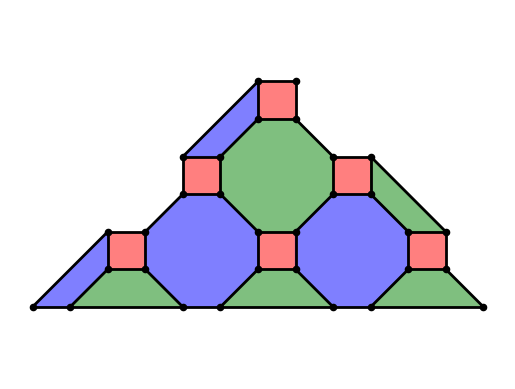

In [6]:
a.plot_layout()

In [8]:
from pecos_rslib.qasm_sim import (
    qasm_sim,
    QuantumEngine,
    DepolarizingNoise,
)

In [11]:
from pecos.slr import Main, SlrConverter, CReg
from pecos.qeclib import qubit as qb

d = 5

prog = Main(
    
    c := Color488Patch("a", d, num_ancillas=4),  # << Logical qubit
    qb.X(a.d[1]), # inject error
        
    syn0 := CReg(f"syn0", c.num_data - 1),
    syn1 := CReg(f"syn1", c.num_data - 1),
    
    c.bare_syn_extract(syn0),
    c.bare_syn_extract(syn1),
)

qasm = SlrConverter(prog).qasm()

In [12]:
data = (
    qasm_sim(qasm)
        .quantum_engine(QuantumEngine.SparseStabilizer)
        .with_binary_string_format()
        .run(5)
)
data

{'syn0': ['1000101100000011',
  '1101010100000011',
  '1110010100000011',
  '1111101100000011',
  '0101000100000011'],
 'syn1': ['1000101100000011',
  '1101010100000011',
  '1110010100000011',
  '1111101100000011',
  '0101000100000011']}

In [16]:
from pecos.slr import Main, SlrConverter, CReg
from pecos.qeclib import qubit as qb

d = 5

prog = Main(
    
    c := Color488Patch("a", d, num_ancillas=4),  # << Logical qubit
    # qb.X(a.d[1]),  # inject error
)

rounds = d
syns = []

for i in range(rounds):
    
    # if i == 1:
    #     prog.extend(qb.Y(a.d[1]))
        
    prog.extend(
        syn := CReg(f"syn{i}", c.num_data - 1),
        c.bare_syn_extract(syn),
    )

    syns.append(syn)

# Calculate syn diff in program
prog.extend(
    diff := CReg("diff", c.num_data - 1),
    diff.set(syns[0] ^ syns[1])
)

qasm = SlrConverter(prog).qasm()

In [17]:
from pecos_rslib.qasm_sim import (
    qasm_sim,
    QuantumEngine,
    DepolarizingNoise,
)

In [18]:
data = (
    qasm_sim(qasm)
        .quantum_engine(QuantumEngine.SparseStabilizer)
        .with_binary_string_format()
        .run(5)
)
data

{'diff': ['0000000000000000',
  '0000000000000000',
  '0000000000000000',
  '0000000000000000',
  '0000000000000000'],
 'syn0': ['1011100000000000',
  '0100010000000000',
  '1101111000000000',
  '1101000100000000',
  '1110101000000000'],
 'syn1': ['1011100000000000',
  '0100010000000000',
  '1101111000000000',
  '1101000100000000',
  '1110101000000000'],
 'syn2': ['1011100000000000',
  '0100010000000000',
  '1101111000000000',
  '1101000100000000',
  '1110101000000000'],
 'syn3': ['1011100000000000',
  '0100010000000000',
  '1101111000000000',
  '1101000100000000',
  '1110101000000000'],
 'syn4': ['1011100000000000',
  '0100010000000000',
  '1101111000000000',
  '1101000100000000',
  '1110101000000000']}

In [19]:
from pecos.tools.syndromes import syn_diff

In [20]:
syn_diff(data, [("syn0", "syn1")])

{'syn0_syn1': ['0000000000000000',
  '0000000000000000',
  '0000000000000000',
  '0000000000000000',
  '0000000000000000']}

In [21]:
data = (
    qasm_sim(qasm)
        .with_binary_string_format()
        .noise(DepolarizingNoise(p=0.003))
        .run(5)
)
data

{'diff': ['0000000000000011',
  '0101100001000000',
  '0000000000000000',
  '0000000100000000',
  '0000000000000000'],
 'syn0': ['1111100000000000',
  '1000110000000000',
  '1010101100000000',
  '1101100100000000',
  '0110100000000000'],
 'syn1': ['1111100000000011',
  '1101010001000000',
  '1010101100000000',
  '1101100000000000',
  '0110100000000000'],
 'syn2': ['0110100000000001',
  '1101010001011000',
  '1111101100000000',
  '1101100100000000',
  '0110000000000000'],
 'syn3': ['0110100000000011',
  '1101010001011000',
  '1111101100000000',
  '1101100000000000',
  '0110010000011100'],
 'syn4': ['0110100000000011',
  '1101110000011000',
  '1111101100000000',
  '1101100100000000',
  '0110010000001100']}

In [22]:
syn_diff(data, [("syn0", "syn1")])

{'syn0_syn1': ['0000000000000011',
  '0101100001000000',
  '0000000000000000',
  '0000000100000000',
  '0000000000000000']}

In [23]:
prog = Main(
    c := Color488Patch("a", distance=5, num_ancillas=4),
    meas := CReg("meas", c.num_data),
)

rounds = 3
syn_preps = [CReg(f"syn_prep_{i}", c.num_data - 1) for i in range(rounds)]

prog.extend(
    *syn_preps,
    c.bare_prep_z(syn_preps),
    c.h(),
    c.meas_z(meas),
)


qasm = SlrConverter(prog).qasm()

print(qasm)

OPENQASM 2.0;
include "hqslib1.inc";
qreg a_d[17];
qreg a_a[4];
creg meas[17];
creg syn_prep_0[16];
creg syn_prep_1[16];
creg syn_prep_2[16];
reset a_d[0];
reset a_d[1];
reset a_d[2];
reset a_d[3];
reset a_d[4];
reset a_d[5];
reset a_d[6];
reset a_d[7];
reset a_d[8];
reset a_d[9];
reset a_d[10];
reset a_d[11];
reset a_d[12];
reset a_d[13];
reset a_d[14];
reset a_d[15];
reset a_d[16];
// Check['Z', [0, 2, 3, 1]] -> syn_prep_0[0]
// Check['Z', [1, 3, 6, 7]] -> syn_prep_0[1]
// Check['Z', [12, 13, 8, 4]] -> syn_prep_0[2]
// Check['Z', [4, 8, 9, 5]] -> syn_prep_0[3]
// Check['Z', [2, 5, 9, 14, 15, 10, 6, 3]] -> syn_prep_0[4]
// Check['Z', [6, 10, 11, 7]] -> syn_prep_0[5]
// Check['Z', [8, 13, 14, 9]] -> syn_prep_0[6]
// Check['Z', [10, 15, 16, 11]] -> syn_prep_0[7]
// Check['X', [0, 2, 3, 1]] -> syn_prep_0[8]
// Check['X', [1, 3, 6, 7]] -> syn_prep_0[9]
// Check['X', [12, 13, 8, 4]] -> syn_prep_0[10]
// Check['X', [4, 8, 9, 5]] -> syn_prep_0[11]
// Check['X', [2, 5, 9, 14, 15, 10, 6, 3]] -

In [24]:
data = (
    qasm_sim(qasm)
        .quantum_engine(QuantumEngine.SparseStabilizer)
        .with_binary_string_format()
        .run(5)
)
data

{'meas': ['00001010110011100',
  '01010100111101101',
  '01011000001101011',
  '10010110100000000',
  '11110001011010111'],
 'syn_prep_0': ['1101010000000000',
  '0011001100000000',
  '1110101100000000',
  '1001100000000000',
  '0101001100000000'],
 'syn_prep_1': ['1101010000000000',
  '0011001100000000',
  '1110101100000000',
  '1001100000000000',
  '0101001100000000'],
 'syn_prep_2': ['1101010000000000',
  '0011001100000000',
  '1110101100000000',
  '1001100000000000',
  '0101001100000000']}

In [25]:
# Helper funciton to extract syndromes and logical measurement... or ... have the program do that...

In [26]:
from pecos.slr import Main, Block, QReg, CReg, Parallel
from pecos.qeclib import qubit as qb

prog = Main(                       
    q := QReg("q", 6),             
    c := CReg("m", 6),             
    Parallel(                      
        Block(  # Bell pair 1      
            qb.H(q[0]),            
            qb.CX(q[0], q[1]),     
        ),                         
        Block(  # Bell pair 2      
            qb.H(q[2]),            
            qb.CX(q[2], q[3]),     
        ),                         
        Block(  # Bell pair 3      
            qb.H(q[4]),            
            qb.CX(q[4], q[5]),     
        ),                         
    ),                             
    qb.Measure(q) > c,             
)                                  
qasm = SlrConverter(prog, optimize_parallel=False).qasm()
print(qasm)

OPENQASM 2.0;
include "hqslib1.inc";
qreg q[6];
creg m[6];
h q[0];
cx q[0], q[1];
h q[2];
cx q[2], q[3];
h q[4];
cx q[4], q[5];
measure q -> m;


In [27]:
from pecos.slr import Main, Block, QReg, CReg, Parallel
from pecos.qeclib import qubit as qb

prog = Main(                       
    q := QReg("q", 6),             
    c := CReg("m", 6),             
    Parallel(                      
        Block(  # Bell pair 1      
            qb.H(q[0]),            
            qb.CX(q[0], q[1]),     
        ),                         
        Block(  # Bell pair 2      
            qb.H(q[2]),            
            qb.CX(q[2], q[3]),     
        ),                         
        Block(  # Bell pair 3      
            qb.H(q[4]),            
            qb.CX(q[4], q[5]),     
        ),                         
    ),                             
    qb.Measure(q) > c,             
)                                  
qasm = SlrConverter(prog, optimize_parallel=True).qasm()
print(qasm)

OPENQASM 2.0;
include "hqslib1.inc";
qreg q[6];
creg m[6];
h q[0];
h q[2];
h q[4];
cx q[0], q[1];
cx q[2], q[3];
cx q[4], q[5];
measure q -> m;


In [28]:
data = (
    qasm_sim(qasm)
        .with_binary_string_format()
        .run(20))
data

{'m': ['001111',
  '111100',
  '001100',
  '000000',
  '001111',
  '000000',
  '001100',
  '001111',
  '000011',
  '000011',
  '001111',
  '000000',
  '000011',
  '000000',
  '000000',
  '111111',
  '110000',
  '110011',
  '110000',
  '001100']}